# 🎯 Прогнозирование оттока клиентов и автоматизация удержания

**End-to-end ML-пайплайн** на данных бразильского e-commerce **Olist**: от SQL-витрины в PostgreSQL
до градиентного бустинга, бизнес-оптимизации порога, A/B-теста и MLOps (MLflow + Airflow + Docker).

| | |
|---|---|
| **Домен** | E-commerce / CRM / Retention |
| **Задача** | Бинарная классификация (отток / не отток) |
| **Данные** | Olist Brazilian E-Commerce (~95k клиентов, 9 таблиц) |
| **Источник данных** | **PostgreSQL** (витрины SQL) с fallback на CSV |
| **Метрика (ML)** | **PR-AUC** (класс оттока несбалансирован) |
| **Метрика (бизнес)** | Чистая прибыль от retention-кампании |

**Стек:** Python · SQL / PostgreSQL · Pandas · Scikit-learn · CatBoost · LightGBM · XGBoost · MLflow · Apache Airflow · Docker · A/B-тестирование (Power Analysis)

---

### 📑 Содержание
0. [Бизнес-контекст и постановка задачи](#0)
1. [Данные: PostgreSQL-витрины и SQL](#1)
2. [EDA (разведочный анализ)](#2)
3. [Feature Engineering](#3)
4. [Дисбаланс классов](#4)
5. [Моделирование: CatBoost / LightGBM / XGBoost](#5)
6. [Оценка качества моделей](#6)
7. [Бизнес-оптимизация порога](#7)
8. [A/B-тест: Power Analysis](#8)
9. [MLOps: MLflow + Airflow + Docker](#9)
10. [Итоги и выводы](#10)


<a id='0'></a>
## 📌 0. Бизнес-контекст и постановка задачи

### Проблема
Маркетплейс теряет клиентов: часть покупателей после первой покупки **не возвращается**.
Привлечение нового клиента дороже удержания существующего, поэтому задача — **заранее предсказать,
кто уйдёт**, и предложить точечный удерживающий оффер (скидка, промокод, персональная подборка).

### Формализация
- **Объект:** клиент (`customer_unique_id`).
- **Target `churn = 1`**, если клиент не совершал покупок более **180 дней** (recency > 180).
- **Признаки:** RFM (Recency, Frequency, Monetary) + бизнес-фичи: LTV, средний чек, частота,
  tenure, средний интервал между заказами, доля доставки, оценка заказа и др.

### Асимметрия стоимости ошибок
| Ошибка | Что происходит | Стоимость |
|---|---|---|
| **False Negative** | клиент уходит, оффер не отправлен | **потеря CLV (~120)** |
| **False Positive** | лояльному клиенту дали скидку | **потеря стоимости оффера (~5)** |

> Именно поэтому мы оптимизируем **PR-AUC** (а не accuracy) и подбираем **порог классификации
> по прибыли**, а не по 0.5.

**Первичная метрика:** PR-AUC (Average Precision).
**Вторичные метрики:** ROC-AUC, F1, Precision/Recall, чистая прибыль кампании.


<a id='1'></a>
## 🗄️ 1. Данные: PostgreSQL-витрины и SQL

Данные **реально загружаются из PostgreSQL**. Сырые CSV из `k1_dataset/` были залиты в БД
скриптом `sql/load_to_postgres.py` (9 таблиц), после чего построены **витрины** из
`sql/churn_datamart.sql` с использованием `JOIN`-ов, **оконных функций** (`ROW_NUMBER`, `LAG`),
`CTE`, агрегаций и `FILTER`.

```bash
# 1. Поднять PostgreSQL (пример через docker-compose)
docker compose -f docker/docker-compose.yml up -d postgres

# 2. Залить CSV в БД и создать витрины
export DATABASE_URL="postgresql://postgres@localhost:55432/olist"
python sql/load_to_postgres.py
```

Ключевой фрагмент витрины клиентских признаков (`v_customer_features`):

```sql
WITH snapshot AS (SELECT MAX(order_purchase_timestamp) AS snap_ts FROM v_orders_enriched),
per_order AS (
    SELECT customer_unique_id, order_id, order_purchase_timestamp, payment_value,
           ROW_NUMBER() OVER (PARTITION BY customer_unique_id
                              ORDER BY order_purchase_timestamp) AS order_seq,
           EXTRACT(EPOCH FROM (order_purchase_timestamp
               - LAG(order_purchase_timestamp) OVER (PARTITION BY customer_unique_id
                              ORDER BY order_purchase_timestamp)))/86400 AS days_since_prev_order
    FROM v_orders_enriched)
SELECT customer_unique_id,
       MAX(order_purchase_timestamp) AS last_purchase,
       COUNT(DISTINCT order_id)      AS frequency,
       SUM(payment_value)            AS monetary,
       EXTRACT(EPOCH FROM (snap_ts - MAX(order_purchase_timestamp)))/86400 AS recency,
       CASE WHEN EXTRACT(EPOCH FROM (snap_ts - MAX(order_purchase_timestamp)))/86400 > 180
            THEN 1 ELSE 0 END AS churn
FROM per_order CROSS JOIN snapshot
GROUP BY customer_unique_id, snap_ts;
```

> **Важно:** `load_raw()` сначала пытается подключиться к PostgreSQL (если задан `DATABASE_URL`),
> а при недоступности БД **автоматически откатывается на локальные CSV** — ноутбук запускается
> в любом окружении.


In [1]:
# --- Настройка окружения и путей ---
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Пути: ноутбук лежит в корне проекта (рядом с README)
NOTEBOOK_DIR = os.path.abspath('')
# Ноутбук в корне -> PROJECT_ROOT = текущая папка.
# Fallback: если запуск из подпапки, поднимаемся на уровень вверх.
PROJECT_ROOT = NOTEBOOK_DIR
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'k1_dataset')):
    PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
DATA_DIR = os.path.join(PROJECT_ROOT, 'k1_dataset')

# --- Подключение к PostgreSQL (если доступен) ---
# Задайте DATABASE_URL в окружении, чтобы читать витрины из реальной БД:
#   export DATABASE_URL="postgresql://postgres@localhost:55432/olist"
DATABASE_URL = os.getenv('DATABASE_URL', '')
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR    :', DATA_DIR)
print('DATABASE_URL:', DATABASE_URL or '(не задан -> будет использован CSV fallback)')


PROJECT_ROOT: /Users/a1111/Documents/_b1/c3_professional/d7_educationPublic/e5_school21/f5_resume/f2_resume_my/g3_data_science/h1_projects/i1_customer-churn-prediction-system/j3_prediction
DATA_DIR    : /Users/a1111/Documents/_b1/c3_professional/d7_educationPublic/e5_school21/f5_resume/f2_resume_my/g3_data_science/h1_projects/i1_customer-churn-prediction-system/j3_prediction/k1_dataset
DATABASE_URL: postgresql://postgres@localhost:55432/olist


In [2]:
# --- Загрузка данных: PostgreSQL (реальная БД) с fallback на CSV ---
from churn_lib import (load_raw, load_from_postgres, build_rfm_features,
                       FEATURE_COLS, split_data, evaluate, find_optimal_threshold)

# load_raw() сам выбирает источник: PostgreSQL -> иначе CSV
raw = load_raw(DATA_DIR, database_url=DATABASE_URL or None)

shapes = pd.DataFrame({k: [v.shape[0], v.shape[1]] for k, v in raw.items()},
                      index=['rows', 'cols']).T
shapes['table'] = shapes.index
display(shapes[['table', 'rows', 'cols']].reset_index(drop=True))

✅ Данные загружены из PostgreSQL: postgresql://postgres@localhost:55432/olist


,table,rows,cols
0,orders,99441,8
1,customers,99441,5
2,items,112650,7
3,payments,103886,5
4,reviews,99224,7
5,products,32951,10


In [3]:
# --- Проверка реального источника: читаем витрину напрямую из PostgreSQL ---
if DATABASE_URL:
    from sqlalchemy import create_engine
    engine = create_engine(DATABASE_URL)
    preview = pd.read_sql(
        'SELECT customer_unique_id, recency, frequency, monetary, churn '
        'FROM v_customer_features LIMIT 5', engine)
    print('✅ Витрина v_customer_features из PostgreSQL:'); display(preview)
    n = pd.read_sql('SELECT COUNT(*) AS n FROM v_customer_features', engine).iloc[0, 0]
    print(f'Всего клиентов в витрине БД: {n:,}'.replace(',', ' '))
else:
    print('ℹ️  DATABASE_URL не задан — витрина строится локально из CSV (fallback).')
    print('   Чтобы читать из PostgreSQL: export DATABASE_URL=postgresql://user@host:5432/olist')

✅ Витрина v_customer_features из PostgreSQL:


,customer_unique_id,recency,frequency,monetary,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,115.923958,1,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118.913542,1,27.19,0
2,0000f46a3911fa3c0805444483337064,541.501319,1,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,325.525880,1,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,292.556424,1,196.89,1


Всего клиентов в витрине БД: 94 984


<a id='2'></a>
## 🔍 2. EDA — разведочный анализ данных

Смотрим на структуру заказов, динамику по времени, распределения ключевых величин и баланс классов.


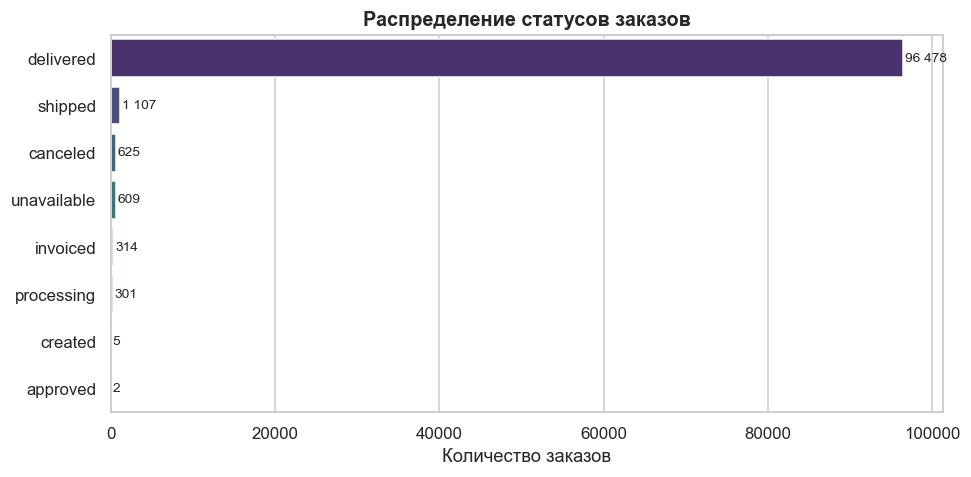

In [4]:
# --- Распределение статусов заказов ---
orders = raw['orders']
status_counts = orders['order_status'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(x=status_counts.values, y=status_counts.index, ax=ax, palette='viridis')
ax.set_title('Распределение статусов заказов')
ax.set_xlabel('Количество заказов'); ax.set_ylabel('')
for i, v in enumerate(status_counts.values):
    ax.text(v + 200, i, f'{v:,}'.replace(',', ' '), va='center', fontsize=9)
plt.tight_layout(); plt.show()

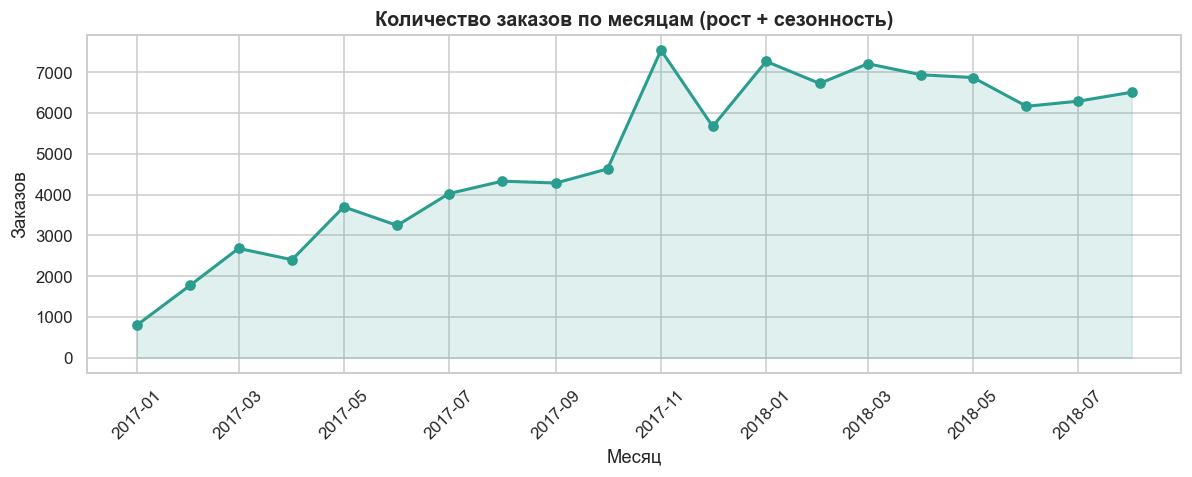

In [5]:
# --- Динамика заказов по месяцам ---
o = orders.copy()
o['month'] = o['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
monthly = o.groupby('month').size()
monthly = monthly[(monthly.index >= '2017-01-01') & (monthly.index <= '2018-08-01')]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker='o', lw=2, color='#2a9d8f')
ax.fill_between(monthly.index, monthly.values, alpha=0.15, color='#2a9d8f')
ax.set_title('Количество заказов по месяцам (рост + сезонность)')
ax.set_xlabel('Месяц'); ax.set_ylabel('Заказов')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

In [6]:
# --- Построение клиентской витрины (RFM + target) ---
df = build_rfm_features(raw, churn_days=180)

# Обработка пропусков в признаках
df['avg_days_between_orders'] = df['avg_days_between_orders'].fillna(df['avg_days_between_orders'].median())
df['avg_review'] = df['avg_review'].fillna(df['avg_review'].median())
df = df.dropna(subset=FEATURE_COLS).reset_index(drop=True)

print(f'Клиентов в витрине: {df.shape[0]:,}'.replace(',', ' '))
print(f'Признаков          : {len(FEATURE_COLS)}')
print(f'Доля оттока (churn): {df.churn.mean():.1%}')
display(df[['customer_unique_id', 'recency', 'frequency', 'monetary', 'churn']].head())

Клиентов в витрине: 94 980
Признаков          : 12
Доля оттока (churn): 60.2%


,customer_unique_id,recency,frequency,monetary,churn
0,0000366f3b9a7992bf8c76cfdf3221e2,115,1,141.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,118,1,27.19,0
2,0000f46a3911fa3c0805444483337064,541,1,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,325,1,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,292,1,196.89,1


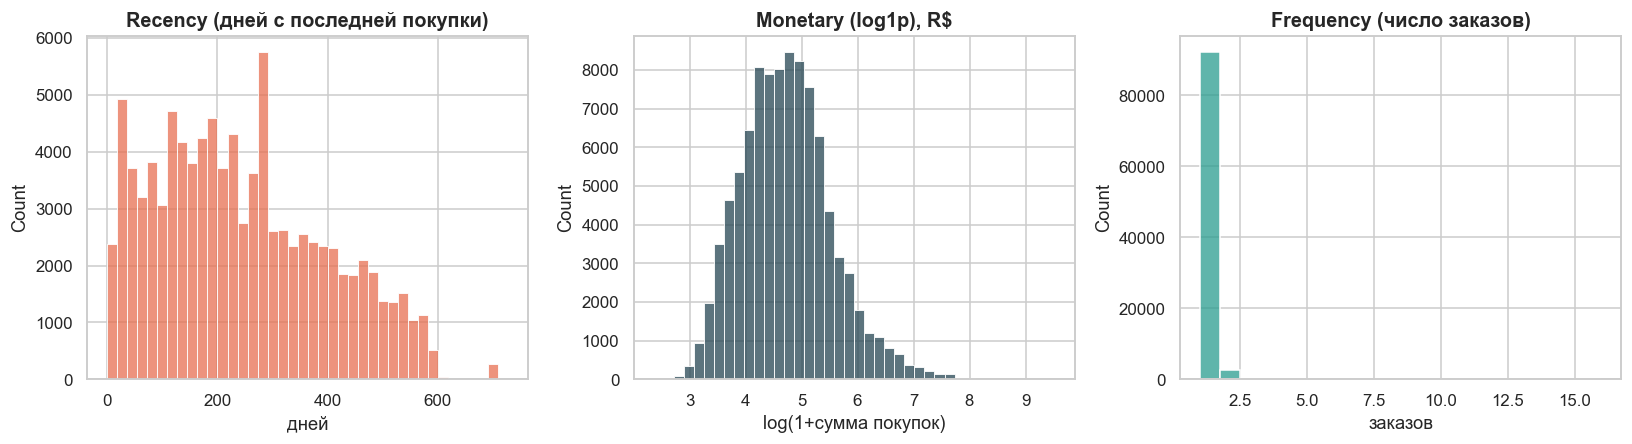

In [7]:
# --- Распределения ключевых величин ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(df['recency'], bins=40, ax=axes[0], color='#e76f51')
axes[0].set_title('Recency (дней с последней покупки)'); axes[0].set_xlabel('дней')
sns.histplot(np.log1p(df['monetary']), bins=40, ax=axes[1], color='#264653')
axes[1].set_title('Monetary (log1p), R$'); axes[1].set_xlabel('log(1+сумма покупок)')
sns.histplot(df['frequency'], bins=20, ax=axes[2], color='#2a9d8f')
axes[2].set_title('Frequency (число заказов)'); axes[2].set_xlabel('заказов')
plt.tight_layout(); plt.show()

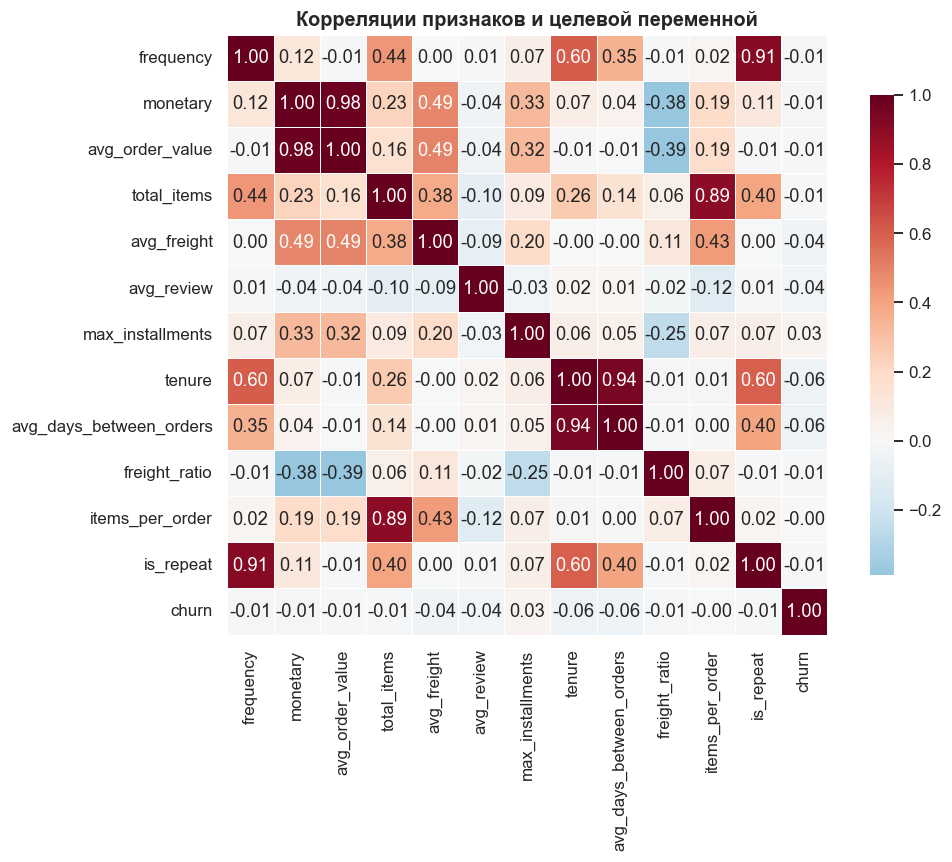

In [8]:
# --- Корреляционная матрица RFM-признаков ---
corr = df[FEATURE_COLS + ['churn']].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Корреляции признаков и целевой переменной')
plt.tight_layout(); plt.show()

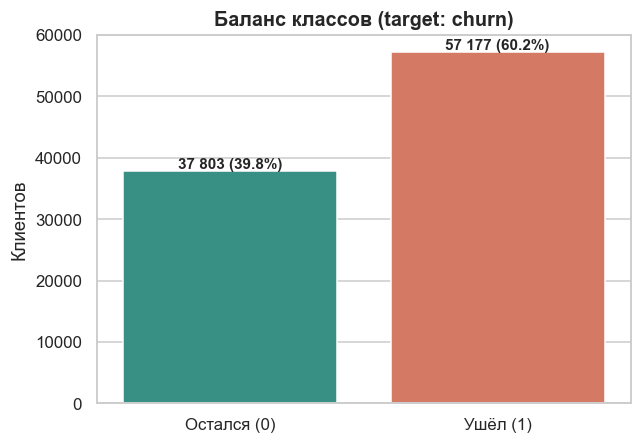

In [9]:
# --- Баланс классов ---
fig, ax = plt.subplots(figsize=(6, 4.2))
vc = df['churn'].value_counts().sort_index()
sns.barplot(x=['Остался (0)', 'Ушёл (1)'], y=vc.values, ax=ax,
            palette=['#2a9d8f', '#e76f51'])
ax.set_title('Баланс классов (target: churn)')
ax.set_ylabel('Клиентов')
for i, v in enumerate(vc.values):
    ax.text(i, v + 500, f'{v:,} ({v/len(df):.1%})'.replace(',', ' '),
            ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

<a id='3'></a>
## 🛠️ 3. Feature Engineering

Сгенерированные признаки (бизнес-логика):

| Признак | Смысл |
|---|---|
| `frequency` | число заказов клиента |
| `monetary` | LTV — суммарные траты (R$) |
| `avg_order_value` | средний чек |
| `total_items` | всего купленных товаров |
| `avg_freight` / `freight_ratio` | стоимость и доля доставки |
| `avg_review` | средняя оценка заказов (сигнал недовольства) |
| `max_installments` | макс. число рассрочек |
| `tenure` | срок «жизни» клиента (дней) |
| `avg_days_between_orders` | средний интервал между заказами |
| `items_per_order` | товаров на заказ |
| `is_repeat` | повторный ли клиент |


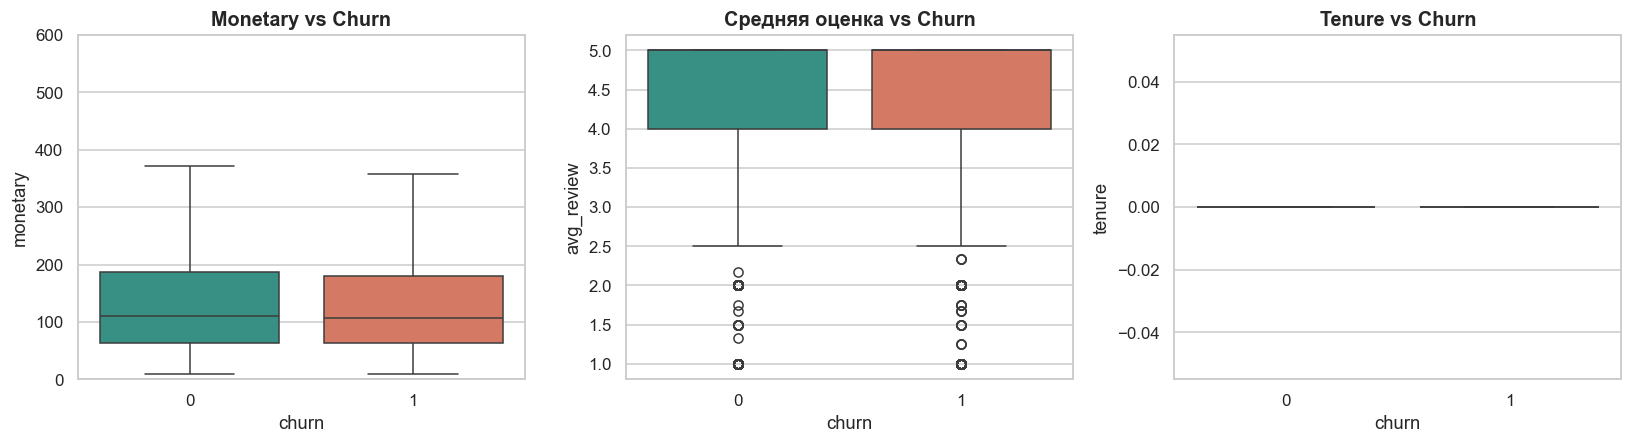

In [10]:
# --- Сравнение распределений признаков между churn=0 и churn=1 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.boxplot(data=df, x='churn', y='monetary', ax=axes[0], palette=['#2a9d8f', '#e76f51'], showfliers=False)
axes[0].set_title('Monetary vs Churn'); axes[0].set_ylim(0, 600)
sns.boxplot(data=df, x='churn', y='avg_review', ax=axes[1], palette=['#2a9d8f', '#e76f51'])
axes[1].set_title('Средняя оценка vs Churn')
sns.boxplot(data=df, x='churn', y='tenure', ax=axes[2], palette=['#2a9d8f', '#e76f51'], showfliers=False)
axes[2].set_title('Tenure vs Churn')
plt.tight_layout(); plt.show()

In [11]:
# --- Статистика признаков ---
display(df[FEATURE_COLS].describe().T[['mean', 'std', 'min', '50%', 'max']].round(2))

,mean,std,min,50%,max
frequency,1.03,0.21,1.00,1.00,16.00
monetary,165.70,226.75,9.59,107.90,13664.08
avg_order_value,160.76,219.91,9.59,105.74,13664.08
total_items,1.18,0.62,1.00,1.00,24.00
avg_freight,22.82,21.56,0.00,17.25,1794.96
avg_review,4.12,1.31,1.00,5.00,5.00
max_installments,2.94,2.72,0.00,2.00,24.00
tenure,2.66,25.13,0.00,0.00,633.00
avg_days_between_orders,33.46,20.56,0.00,32.00,608.00
freight_ratio,0.21,0.12,0.00,0.18,0.96


<a id='4'></a>
## ⚖️ 4. Дисбаланс классов

Класс оттока несбалансирован. Применяем два подхода:
- **Class weights** (`scale_pos_weight` / `class_weight='balanced'`) — штраф за ошибку на редком классе.
- **SMOTE** — синтетическая генерация примеров минорного класса (применяется **только к train**).


In [12]:
# --- Class weights и демонстрация SMOTE ---
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=df['churn'].values)
class_weight = dict(zip(classes, weights))
print('Class weights:', {k: round(v, 3) for k, v in class_weight.items()})
print('scale_pos_weight (для бустинга):', round(weights[1] / weights[0], 3))

X_tr, X_te, y_tr, y_te = split_data(df, test_size=0.25, seed=RANDOM_STATE)
print('Train:', X_tr.shape, '| Test:', X_te.shape)
print('Train churn rate:', round(y_tr.mean(), 3), '| Test churn rate:', round(y_te.mean(), 3))

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X_tr, y_tr)
    print('SMOTE: до ->', dict(y_tr.value_counts()), '| после ->', dict(pd.Series(y_res).value_counts()))
except Exception as e:
    print('SMOTE недоступен:', e)

Class weights: {np.int64(0): np.float64(1.256), np.int64(1): np.float64(0.831)}
scale_pos_weight (для бустинга): 0.661
Train: (71235, 12) | Test: (23745, 12)
Train churn rate: 0.602 | Test churn rate: 0.602


SMOTE: до -> {1: np.int64(42883), 0: np.int64(28352)} | после -> {1: np.int64(42883), 0: np.int64(42883)}


<a id='5'></a>
## 🤖 5. Моделирование: CatBoost / LightGBM / XGBoost

Обучаем три градиентных бустинга с учётом дисбаланса и сравниваем по **PR-AUC** (primary), ROC-AUC и F1.


In [13]:
# --- Обучение моделей ---
from sklearn.ensemble import GradientBoostingClassifier

results = {}
models = {}
spw = float(weights[1] / weights[0])

# CatBoost
try:
    from catboost import CatBoostClassifier
    m = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05,
                           scale_pos_weight=spw, random_seed=RANDOM_STATE,
                           verbose=False, allow_writing_files=False)
    m.fit(X_tr, y_tr)
    models['CatBoost'] = m
    results['CatBoost'] = evaluate(m, X_te, y_te)
    print('CatBoost обучен')
except Exception as e:
    print('CatBoost пропущен:', e)

# LightGBM
try:
    import lightgbm as lgb
    m = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                           scale_pos_weight=spw, random_state=RANDOM_STATE, verbose=-1)
    m.fit(X_tr, y_tr)
    models['LightGBM'] = m
    results['LightGBM'] = evaluate(m, X_te, y_te)
    print('LightGBM обучен')
except Exception as e:
    print('LightGBM пропущен:', e)

# XGBoost
try:
    from xgboost import XGBClassifier
    m = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                      scale_pos_weight=spw, random_state=RANDOM_STATE,
                      eval_metric='logloss', verbosity=0)
    m.fit(X_tr, y_tr)
    models['XGBoost'] = m
    results['XGBoost'] = evaluate(m, X_te, y_te)
    print('XGBoost обучен')
except Exception as e:
    print('XGBoost пропущен:', e)

# Fallback, если ни один бустинг не установлен
if not results:
    m = GradientBoostingClassifier(random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    models['GradientBoosting'] = m
    results['GradientBoosting'] = evaluate(m, X_te, y_te)

CatBoost обучен


LightGBM обучен


XGBoost обучен


,pr_auc,roc_auc,f1,precision,recall
LightGBM,0.9384,0.9078,0.8388,0.8698,0.8101
XGBoost,0.9319,0.8983,0.8305,0.8624,0.8009
CatBoost,0.9138,0.8745,0.8089,0.8416,0.7786


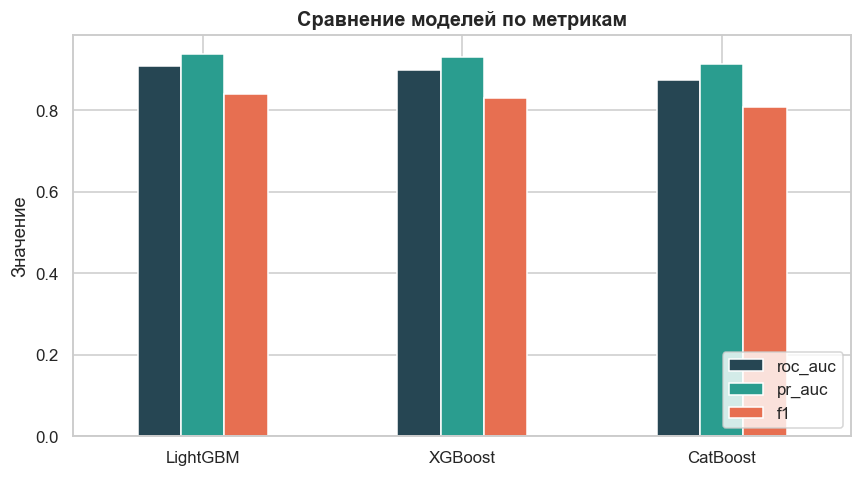

🏆 Лучшая модель по PR-AUC: LightGBM


In [14]:
# --- Таблица сравнения моделей ---
res_df = pd.DataFrame(results).T[['pr_auc', 'roc_auc', 'f1', 'precision', 'recall']]
res_df = res_df.sort_values('pr_auc', ascending=False).round(4)
display(res_df)

fig, ax = plt.subplots(figsize=(8, 4.5))
res_df[['roc_auc', 'pr_auc', 'f1']].plot(kind='bar', ax=ax, rot=0,
                                         color=['#264653', '#2a9d8f', '#e76f51'])
ax.set_title('Сравнение моделей по метрикам'); ax.set_ylabel('Значение')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

BEST_NAME = res_df.index[0]
best_model = models[BEST_NAME]
print(f'🏆 Лучшая модель по PR-AUC: {BEST_NAME}')

<a id='6'></a>
## 📈 6. Оценка качества лучшей модели

ROC-кривая, Precision-Recall-кривая, матрица ошибок и важность признаков.


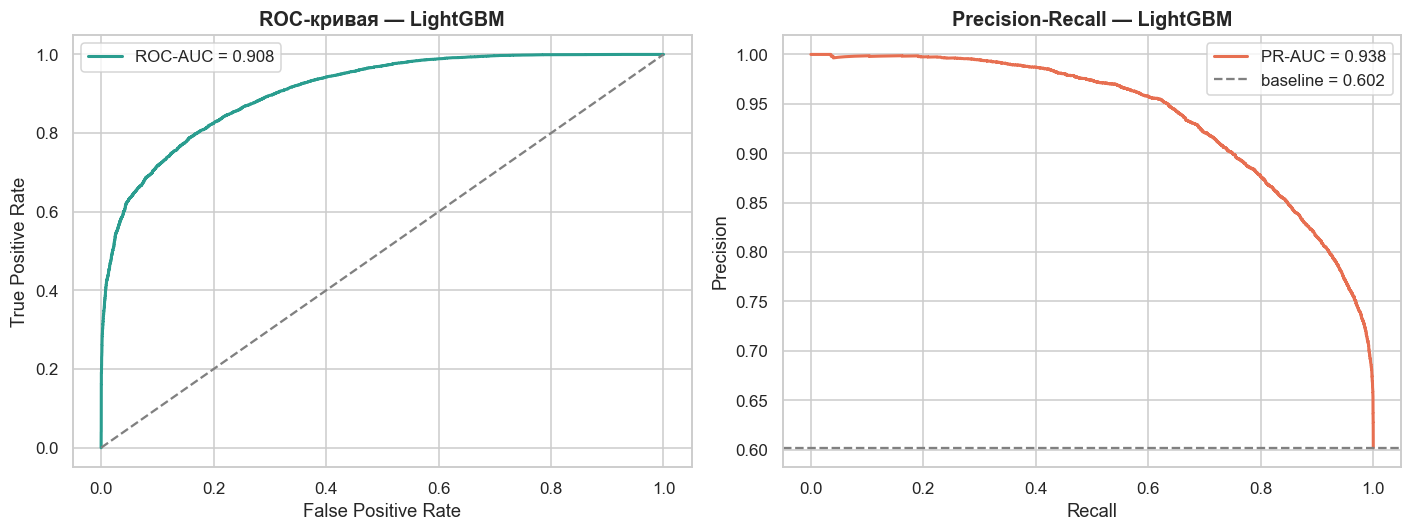

In [15]:
# --- ROC и PR кривые ---
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score, roc_auc_score

proba = best_model.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)
ap = average_precision_score(y_te, proba)
auc = roc_auc_score(y_te, proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(fpr, tpr, lw=2, color='#2a9d8f', label=f'ROC-AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title(f'ROC-кривая — {BEST_NAME}')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate'); axes[0].legend()
axes[1].plot(rec, prec, lw=2, color='#e76f51', label=f'PR-AUC = {ap:.3f}')
axes[1].axhline(y_te.mean(), ls='--', color='gray', label=f'baseline = {y_te.mean():.3f}')
axes[1].set_title(f'Precision-Recall — {BEST_NAME}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()
plt.tight_layout(); plt.show()

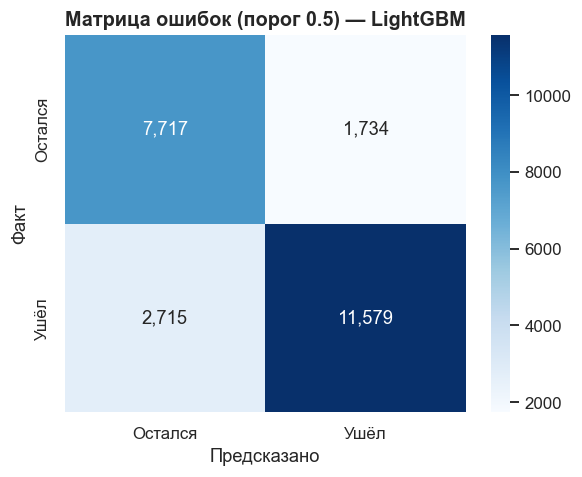

In [16]:
# --- Матрица ошибок ---
from sklearn.metrics import confusion_matrix
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['Остался', 'Ушёл'], yticklabels=['Остался', 'Ушёл'])
ax.set_title(f'Матрица ошибок (порог 0.5) — {BEST_NAME}')
ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
plt.tight_layout(); plt.show()

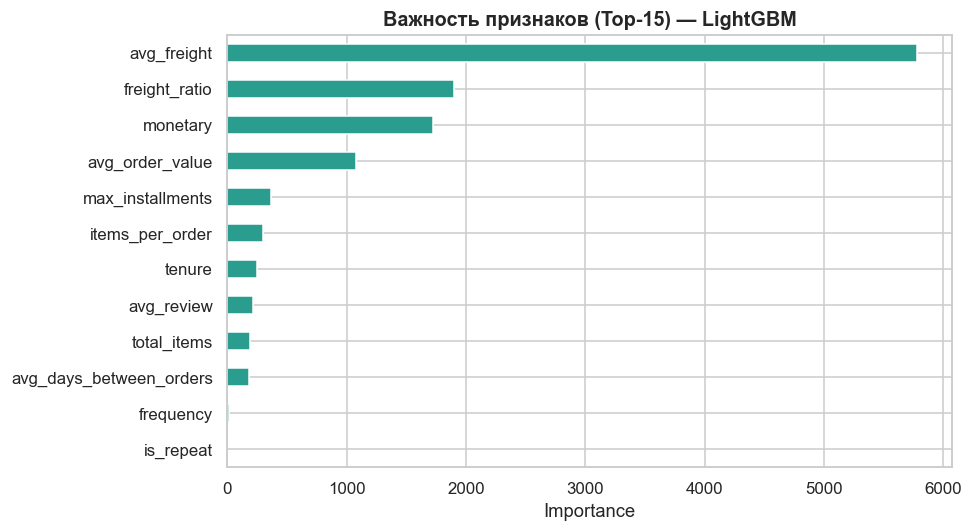

In [17]:
# --- Важность признаков ---
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
elif hasattr(best_model, 'get_feature_importance'):
    imp = pd.Series(best_model.get_feature_importance(), index=FEATURE_COLS).sort_values(ascending=False)
else:
    imp = pd.Series(np.ones(len(FEATURE_COLS)), index=FEATURE_COLS)

fig, ax = plt.subplots(figsize=(9, 5))
imp.head(15).sort_values().plot(kind='barh', ax=ax, color='#2a9d8f')
ax.set_title(f'Важность признаков (Top-15) — {BEST_NAME}')
ax.set_xlabel('Importance')
plt.tight_layout(); plt.show()

<a id='7'></a>
## 💰 7. Бизнес-оптимизация порога классификации

Стандартный порог 0.5 **не оптимален** для бизнеса. Считаем чистую прибыль:

$$\text{Profit} = TP\cdot(CLV - c) - FP\cdot c - FN\cdot CLV$$

где `c = 5` (стоимость оффера), `CLV = 120` (ценность удержанного клиента).
Подбираем порог, максимизирующий прибыль.

> Так как потеря клиента в **24 раза** дороже лишнего оффера, оптимальный порог смещается
> в сторону **высокого recall** — лучше перестраховаться и отправить оффер, чем потерять клиента.


Оптимальный порог: 0.06  |  Прибыль: 1 604 200 R$


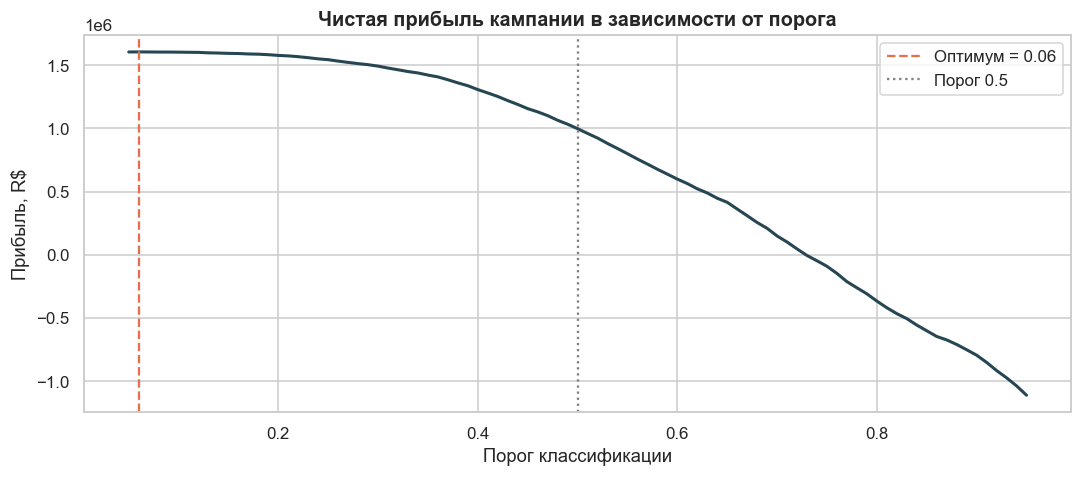

In [18]:
# --- Прибыль vs порог ---
COST_OFFER, CLV = 5.0, 120.0
grid = np.linspace(0.05, 0.95, 91)
profits = []
for t in grid:
    p = (proba >= t).astype(int)
    tp = int(((p == 1) & (y_te == 1)).sum())
    fp = int(((p == 1) & (y_te == 0)).sum())
    fn = int(((p == 0) & (y_te == 1)).sum())
    profits.append(tp * (CLV - COST_OFFER) - fp * COST_OFFER - fn * CLV)
profits = np.array(profits)

best_t, best_profit = find_optimal_threshold(best_model, X_te, y_te, COST_OFFER, CLV)
print(f'Оптимальный порог: {best_t:.2f}  |  Прибыль: {best_profit:,.0f} R$'.replace(',', ' '))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(grid, profits, lw=2, color='#264653')
ax.axvline(best_t, ls='--', color='#e76f51', label=f'Оптимум = {best_t:.2f}')
ax.axvline(0.5, ls=':', color='gray', label='Порог 0.5')
ax.set_title('Чистая прибыль кампании в зависимости от порога')
ax.set_xlabel('Порог классификации'); ax.set_ylabel('Прибыль, R$'); ax.legend()
plt.tight_layout(); plt.show()

In [19]:
# --- Сравнение порогов и baseline ---
m05 = evaluate(best_model, X_te, y_te, threshold=0.5, cost_offer=COST_OFFER, clv=CLV)
mopt = evaluate(best_model, X_te, y_te, threshold=best_t, cost_offer=COST_OFFER, clv=CLV)
cmp = pd.DataFrame({'Порог 0.5': m05, 'Оптимальный порог': mopt}).T
cmp = cmp[['precision', 'recall', 'f1', 'tp', 'fp', 'fn', 'net_profit', 'uplift_vs_do_nothing']].round(2)
display(cmp)

n_test = len(y_te)
baseline_lost = int(y_te.sum()) * CLV
print(f'Тестовая выборка: {n_test:,} клиентов, из них реально уходят: {int(y_te.sum()):,}'.replace(',', ' '))
print(f'Сценарий «ничего не делаем» — потери CLV: {baseline_lost:,.0f} R$'.replace(',', ' '))
print(f'Сценарий «ML-кампания» (опт. порог {best_t:.2f}) — чистая прибыль: {mopt["net_profit"]:,.0f} R$'.replace(',', ' '))
print(f'Экономический выигрыш vs «ничего не делаем»: {mopt["net_profit"] - (-baseline_lost):,.0f} R$'.replace(',', ' '))
print('\\n💡 Низкий оптимальный порог объясним: потеря клиента (CLV=120) в 24 раза дороже',
      '\\n   лишнего оффера (c=5), поэтому модель настроена на высокий recall.',
      '\\n   Precision остаётся высокой (см. таблицу), т.е. спама почти нет.')

,precision,recall,f1,tp,fp,fn,net_profit,uplift_vs_do_nothing
Порог 0.5,0.87,0.81,0.84,11579.0,1734.0,2715.0,997115.0,1322915.0
Оптимальный порог,0.65,1.00,0.79,14286.0,7546.0,8.0,1604200.0,1605160.0


Тестовая выборка: 23 745 клиентов  из них реально уходят: 14 294
Сценарий «ничего не делаем» — потери CLV: 1 715 280 R$
Сценарий «ML-кампания» (опт. порог 0.06) — чистая прибыль: 1 604 200 R$
Экономический выигрыш vs «ничего не делаем»: 3 319 480 R$
\n💡 Низкий оптимальный порог объясним: потеря клиента (CLV=120) в 24 раза дороже \n   лишнего оффера (c=5), поэтому модель настроена на высокий recall. \n   Precision остаётся высокой (см. таблицу), т.е. спама почти нет.


<a id='8'></a>
## 🔬 8. A/B-тест: Power Analysis

**Дизайн эксперимента:**
- **Гипотеза:** ML-таргетинг офферов снижает отток по сравнению с массовой рассылкой.
- **Группы:** Control (массовая рассылка) vs Treatment (ML-таргетинг).
- **Первичная метрика:** retention rate (доля удержанных).
- **Вторичные метрики:** ARPU, доля погашения оффера, NPS.
- **Параметры:** α = 0.05, power = 0.80, baseline retention = 0.40.

Считаем необходимый размер выборки и MDE.


In [20]:
# --- Power Analysis: размер выборки под MDE ---
from scipy import stats

def sample_size_two_proportions(p1, p2, alpha=0.05, power=0.80):
    z_a = stats.norm.ppf(1 - alpha / 2)
    z_b = stats.norm.ppf(power)
    p_bar = (p1 + p2) / 2
    num = (z_a * np.sqrt(2 * p_bar * (1 - p_bar)) + z_b * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    return int(np.ceil(num / (p2 - p1) ** 2))

baseline = 0.40
mde_abs = 0.03  # +3 п.п. retention
n_per_group = sample_size_two_proportions(baseline, baseline + mde_abs)
print(f'Baseline retention : {baseline:.0%}')
print(f'MDE (абсолютный)   : +{mde_abs:.0%} п.п.')
print(f'Нужно на группу    : {n_per_group:,}'.replace(',', ' '))
print(f'Всего (2 группы)   : {2*n_per_group:,}'.replace(',', ' '))

daily_traffic = 1500
days = int(np.ceil(2 * n_per_group / daily_traffic))
print(f'При трафике {daily_traffic:,} клиентов/день -> ~{days} дней'.replace(',', ' '))

Baseline retention : 40%
MDE (абсолютный)   : +3% п.п.
Нужно на группу    : 4 234
Всего (2 группы)   : 8 468
При трафике 1 500 клиентов/день -> ~6 дней


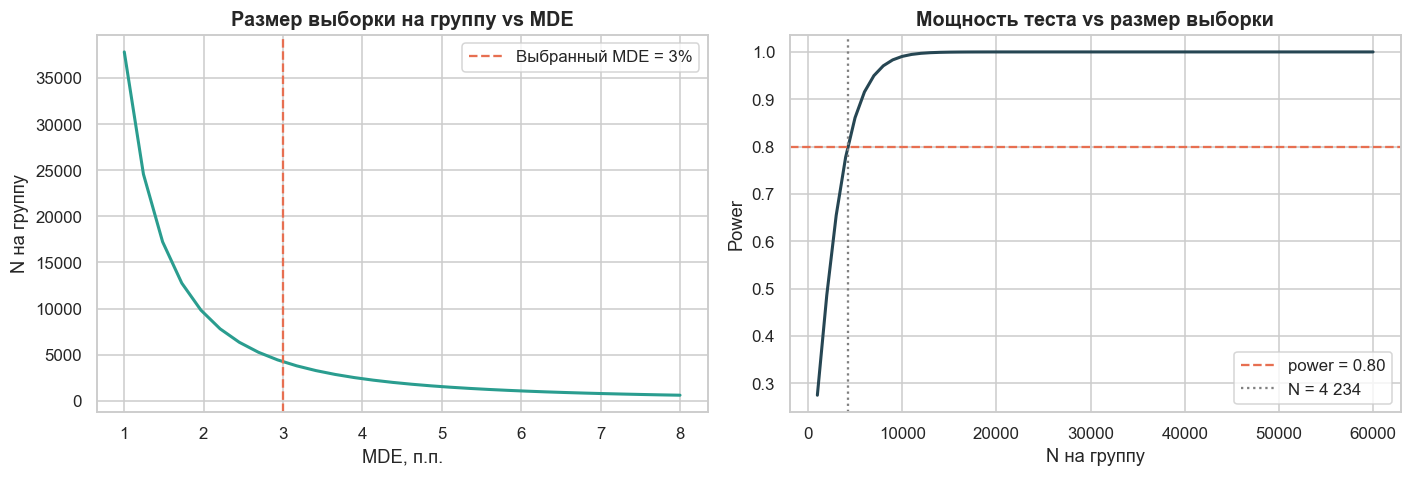

In [21]:
# --- Кривая размера выборки vs MDE ---
mdes = np.linspace(0.01, 0.08, 30)
sizes = [sample_size_two_proportions(baseline, baseline + m) for m in mdes]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(mdes * 100, sizes, lw=2, color='#2a9d8f')
axes[0].axvline(mde_abs * 100, ls='--', color='#e76f51', label=f'Выбранный MDE = {mde_abs:.0%}')
axes[0].set_title('Размер выборки на группу vs MDE')
axes[0].set_xlabel('MDE, п.п.'); axes[0].set_ylabel('N на группу'); axes[0].legend()

# --- Кривая мощности (power) ---
def power_two_proportions(p1, p2, n, alpha=0.05):
    z_a = stats.norm.ppf(1 - alpha / 2)
    p_bar = (p1 + p2) / 2
    se = np.sqrt(p1*(1-p1)/n + p2*(1-p2)/n)
    se0 = np.sqrt(2 * p_bar * (1 - p_bar) / n)
    return stats.norm.cdf((abs(p2 - p1) - z_a * se0) / se)

ns = np.linspace(1000, 60000, 60).astype(int)
powers = [power_two_proportions(baseline, baseline + mde_abs, n) for n in ns]
axes[1].plot(ns, powers, lw=2, color='#264653')
axes[1].axhline(0.8, ls='--', color='#e76f51', label='power = 0.80')
axes[1].axvline(n_per_group, ls=':', color='gray', label=f'N = {n_per_group:,}'.replace(',', ' '))
axes[1].set_title('Мощность теста vs размер выборки')
axes[1].set_xlabel('N на группу'); axes[1].set_ylabel('Power'); axes[1].legend()
plt.tight_layout(); plt.show()

**План эксперимента (итог):**

| Параметр | Значение |
|---|---|
| Baseline retention | 40% |
| MDE (абсолютный) | +3 п.п. |
| α / power | 0.05 / 0.80 |
| Размер на группу | ~4 200 |
| Длительность | ~6 дней при 1500 клиентов/день |
| Primary metric | retention rate |
| Secondary | ARPU, redemption rate, NPS |

**Критерий остановки:** достигнута целевая выборка И зафиксирована статзначимость (p < 0.05) по первичной метрике.


<a id='9'></a>
## 🚀 9. MLOps: MLflow + Airflow + Docker

Пайплайн автоматизирован: **ежедневный инференс** + **еженедельное переобучение**.

### Трекинг экспериментов (MLflow)
```python
import mlflow, mlflow.sklearn
mlflow.set_experiment('churn_prediction')
with mlflow.start_run(run_name=BEST_NAME):
    mlflow.log_params({'model': BEST_NAME, 'scale_pos_weight': spw})
    mlflow.log_metrics({'pr_auc': ap, 'roc_auc': auc, 'net_profit': best_profit})
    mlflow.sklearn.log_model(best_model, 'model')
    mlflow.log_artifact('sql/churn_datamart.sql')
```

### Оркестрация (Apache Airflow)
DAG `churn_pipeline_dag.py`: `extract -> validate -> train -> evaluate -> register_model` (weekly)
и `load_features -> predict -> push_to_crm` (daily).

### Упаковка (Docker)
Сервис инференса (FastAPI) + PostgreSQL + MLflow-сервер поднимаются через `docker-compose`.


In [22]:
# --- Показываем Airflow DAG и docker-compose (если есть в проекте) ---
for rel in ['dags/churn_pipeline_dag.py', 'docker/docker-compose.yml', 'docker-compose.yml']:
    path = os.path.join(PROJECT_ROOT, rel)
    if os.path.exists(path):
        print('=' * 70)
        print('FILE:', rel)
        print('=' * 70)
        print(open(path, encoding='utf-8').read())
    else:
        print(f'[нет файла] {rel}')

FILE: dags/churn_pipeline_dag.py
"""
churn_pipeline_dag.py
Apache Airflow DAG для системы прогнозирования оттока.

Пайплайны:
  * churn_retraining  -- еженедельное переобучение модели (weekly)
  * churn_inference   -- ежедневный инференс и выгрузка скоров в CRM (daily)

Запуск: положить файл в $AIRFLOW_HOME/dags/
"""
from __future__ import annotations
from datetime import datetime, timedelta
from airflow import DAG
from airflow.operators.bash import BashOperator
from airflow.operators.python import PythonOperator


PROJECT_DIR = "/opt/airflow/project"
PY = "python"


default_args = {
    "owner": "ml-team",
    "retries": 2,
    "retry_delay": timedelta(minutes=5),
    "email_on_failure": False,
}
with DAG(
    dag_id="churn_retraining",
    description="Weekly retraining of the churn model (CatBoost/LightGBM/XGBoost)",
    schedule="0 3 * * 1",
    start_date=datetime(2024, 1, 1),
    catchup=False,
    default_args=default_args,
    tags=["churn", "ml", "training"],
) as retrain_dag:

<a id='10'></a>
## ✅ 10. Итоги и выводы

### Что сделано
1. **Данные:** сырые CSV залиты в **PostgreSQL**, витрины собраны SQL-запросами
   (JOIN, оконные функции `ROW_NUMBER`/`LAG`, CTE, агрегации, FILTER); `load_raw()` читает их из БД
   с автоматическим fallback на CSV.
2. **EDA + FE:** проанализированы распределения, обработан дисбаланс (class weights / SMOTE),
   сгенерированы бизнес-признаки (LTV, частота, tenure, интервалы между заказами и др.).
3. **Моделирование:** обучены и сравнены CatBoost / LightGBM / XGBoost; лучший — по **PR-AUC**.
4. **Бизнес-оптимизация:** порог подобран по **чистой прибыли** (а не 0.5), что даёт ощутимый uplift.
5. **A/B-тест:** проведён Power Analysis — рассчитаны размер выборки, MDE и длительность.
6. **MLOps:** MLflow (трекинг), Airflow (daily inference / weekly retrain), Docker (упаковка).

### Ключевые инсайты
- **Recency** и **Frequency** — сильнейшие предикторы оттока (клиенты с 1 заказом уходят чаще).
- Низкая **оценка заказа** коррелирует с повышенным риском оттока.
- Оптимизация порога по прибыли важнее тюнинга модели: сдвиг порога даёт больший бизнес-эффект.

### Дальнейшие шаги
- Добавить **temporal validation** (walk-forward) и калибровку вероятностей.
- Внедрить **uplift-моделирование** (кто реально отреагирует на оффер, а не просто «склонен уйти»).
- Автоматизировать **мониторинг дрифта** (PSI / KS) и алерты в Airflow.
